# Squat Detection & Rep Counting using MediaPipe Pose Estimation

---

**Name:** Hamza Asif  
**Roll No:** 23-AI-93  
**Course:** Computer Vision — CCP Assignment  

**Video Source:** [Jumping Jacks / Burpees — Pixabay](https://pixabay.com/videos/jumping-jacks-burpees-burpee-12963/)

---


## 1. Install Dependencies


In [1]:
!pip install -q mediapipe opencv-python pandas matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.6 MB/s eta 0:00:00


## 2. Imports, Styling, and Constants


In [2]:
import os
import urllib.request
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from google.colab import files

# Modern styling for matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['figure.figsize'] = (12, 6)

# Configuration Constants
INPUT_VIDEO = "squat.mp4"
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task"
MODEL_PATH = "pose_landmarker_full.task"
OUTPUT_VIDEO = "output_skeleton.mp4"
TRACKING_PLOT = "joint_angles_tracking.png"
CONFUSION_MATRIX_PLOT = "confusion_matrix.png"

# MediaPipe Standard Landmark Indices
L_SHOULDER, L_ELBOW, L_WRIST = 11, 13, 15
L_HIP, L_KNEE, L_ANKLE = 23, 25, 27
R_SHOULDER, R_ELBOW, R_WRIST = 12, 14, 16
R_HIP, R_KNEE, R_ANKLE = 24, 26, 28

## 3. Upload Video and Download Model


In [3]:
def download_model(url, dest_path):
    """Downloads the MediaPipe model if it doesn't exist."""
    if not os.path.exists(dest_path):
        print(f"[*] Downloading pose landmarker model...")
        urllib.request.urlretrieve(url, dest_path)
        print("[+] Model download complete!")
    else:
        print("[+] Model already exists. Skipping download.")

# 1. Download Model
download_model(MODEL_URL, MODEL_PATH)

# 2. Upload Video
print("\n[*] Please upload your video file (it will be renamed to 'squat.mp4' automatically)")
uploaded = files.upload()

for filename in uploaded.keys():
    # FIXED LOGIC: Only delete and rename if the uploaded file isn't ALREADY named 'squat.mp4'
    if filename != INPUT_VIDEO:
        if os.path.exists(INPUT_VIDEO):
            os.remove(INPUT_VIDEO)
        os.rename(filename, INPUT_VIDEO)

    print(f"\n[+] Success! '{filename}' has been prepared as '{INPUT_VIDEO}'.")

[*] Downloading pose landmarker model...
[+] Model download complete!

[*] Please upload your video file (it will be renamed to 'squat.mp4' automatically)


Saving input_video.mp4 to input_video.mp4

[+] Success! 'input_video.mp4' has been prepared as 'squat.mp4'.


## 4. Helper Functions


In [4]:
def calculate_angle_2d(pA, pB, pC):
    """Calculates the 2D angle (in degrees) at vertex pB."""
    a, b, c = np.array(pA), np.array(pB), np.array(pC)
    ba, bc = a - b, c - b

    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    return np.degrees(np.arccos(cosine_angle))

def apply_moving_average(data, window_size=5):
    """Applies a simple moving average filter with symmetric padding."""
    if len(data) < window_size: return data
    pad_size = window_size // 2
    padded = np.pad(data, pad_size, mode='edge')
    smoothed = np.convolve(padded, np.ones(window_size)/window_size, mode='valid')
    return smoothed[:len(data)]

def apply_savitzky_golay(data, window_length=11, polyorder=2):
    """Applies a Savitzky-Golay filter to smooth coordinate trajectories."""
    if len(data) <= window_length:
        window_length = len(data) if len(data) % 2 != 0 else len(data) - 1
    if window_length < 3: return data
    return savgol_filter(data, window_length=window_length, polyorder=polyorder)

## 5. Pose Detection Processing


In [5]:
def extract_raw_poses():
    cap = cv2.VideoCapture(INPUT_VIDEO)
    if not cap.isOpened(): raise IOError(f"Cannot open video file: {INPUT_VIDEO}")

    width, height = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps, total_frames = cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"[*] Processing Video: {width}x{height} @ {fps:.2f} FPS | Total Frames: {total_frames}")

    options = vision.PoseLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=vision.RunningMode.VIDEO
    )

    raw_coordinates = []

    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

            timestamp_ms = int((frame_idx * 1000) / fps)
            results = landmarker.detect_for_video(mp_image, timestamp_ms)

            frame_coords = {}
            if results.pose_landmarks and len(results.pose_landmarks) > 0:
                for idx, lm in enumerate(results.pose_landmarks[0]):
                    frame_coords[idx] = (lm.x, lm.y) # Store relative floats for smoother interpolation
            raw_coordinates.append(frame_coords)
            frame_idx += 1

    cap.release()
    print("[+] Raw pose data successfully extracted!")
    return raw_coordinates, fps, width, height, total_frames

raw_coords_list, fps, video_width, video_height, total_frames = extract_raw_poses()

[*] Processing Video: 2048x1152 @ 29.97 FPS | Total Frames: 1356
[+] Raw pose data successfully extracted!


## 6. Data Extraction and Smoothing


In [6]:
joints = {'shoulder': L_SHOULDER, 'hip': L_HIP, 'knee': L_KNEE, 'ankle': L_ANKLE, 'elbow': L_ELBOW, 'wrist': L_WRIST}
trajectories = {}

for name, j_id in joints.items():
    x_coords, y_coords = [], []
    for frame_dict in raw_coords_list:
        if j_id in frame_dict:
            x_coords.append(frame_dict[j_id][0] * video_width) # Convert back to absolute pixels
            y_coords.append(frame_dict[j_id][1] * video_height)
        else:
            x_coords.append(np.nan)
            y_coords.append(np.nan)

    trajectories[f'{name}_x'] = pd.Series(x_coords).interpolate(method='linear').ffill().bfill().values
    trajectories[f'{name}_y'] = pd.Series(y_coords).interpolate(method='linear').ffill().bfill().values

df = pd.DataFrame(trajectories)
df_smoothed_sg = pd.DataFrame()

# Apply aggressive Savitzky-Golay filtering for smoothness
for col in df.columns:
    df_smoothed_sg[col] = apply_savitzky_golay(df[col].values, window_length=15, polyorder=3)

print("[+] Keypoint interpolation and premium smoothing successfully completed.")

[+] Keypoint interpolation and premium smoothing successfully completed.


## 7. Angle Tracking

We compute **Knee**, **Hip**, and **Elbow** angles across all frames using the smoothed keypoint coordinates, then plot all three over time to visualize activity transitions.


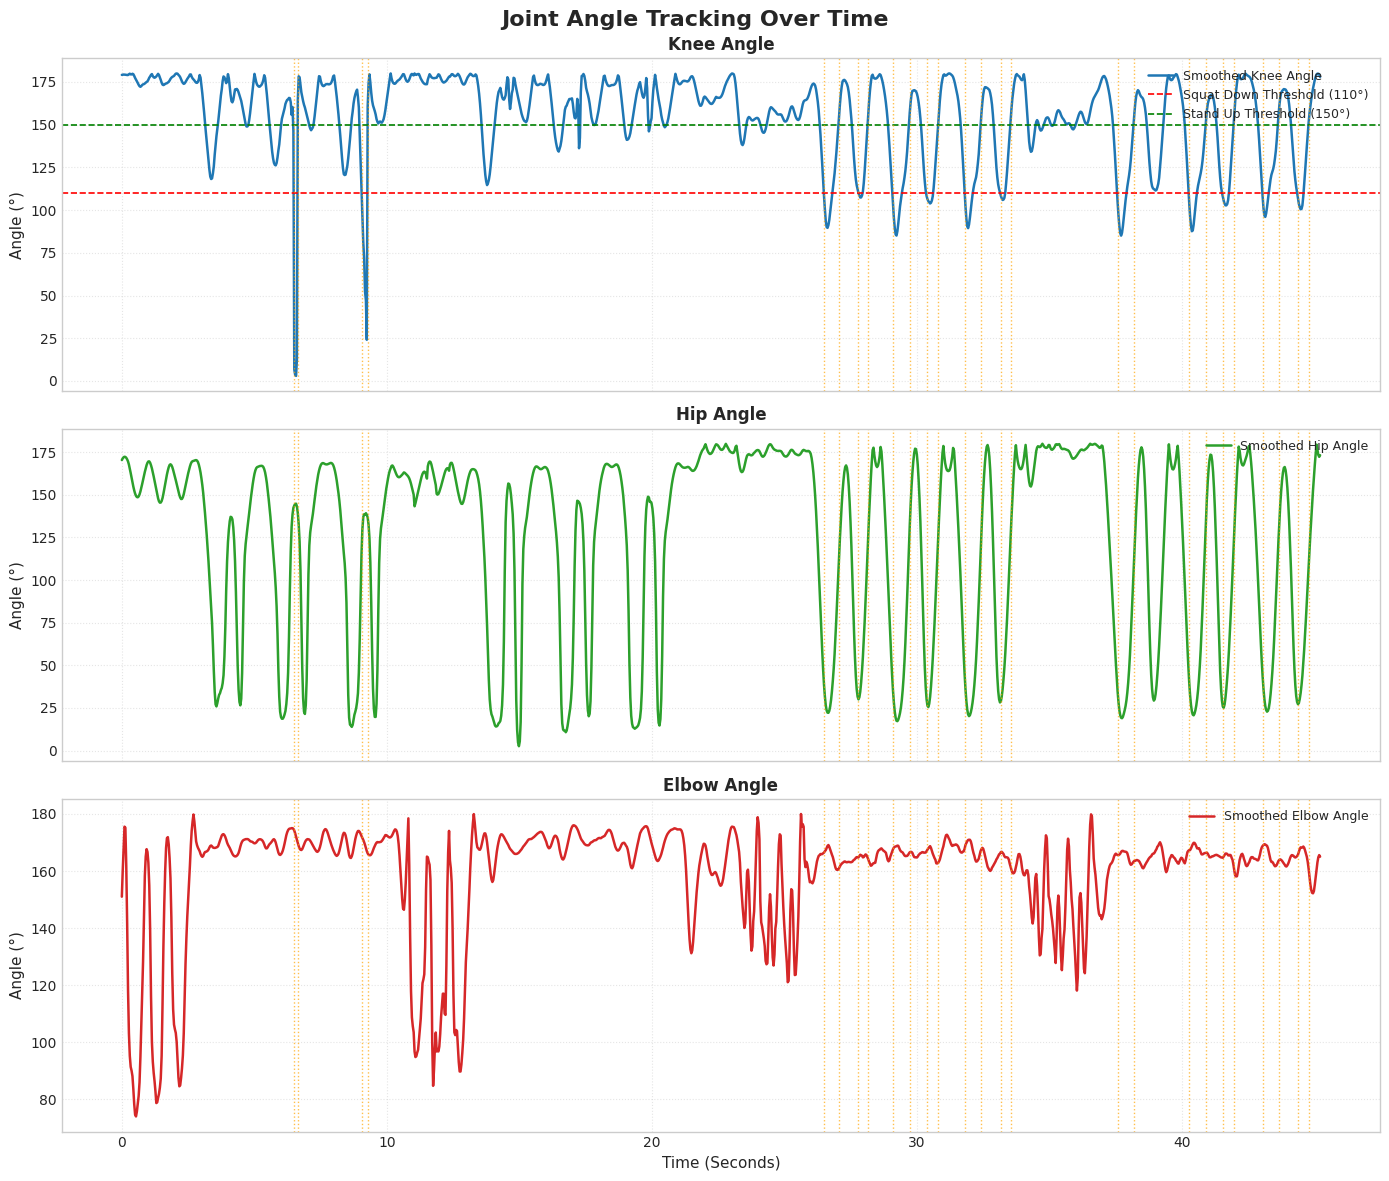

[+] Angle calculations complete. Detected 26 activity transitions (orange lines).
[+] Transition times (seconds): [np.float64(6.51), np.float64(6.64), np.float64(9.08), np.float64(9.28), np.float64(26.49), np.float64(27.06), np.float64(27.79), np.float64(28.16), np.float64(29.1), np.float64(29.73), np.float64(30.36), np.float64(30.8), np.float64(31.83), np.float64(32.43), np.float64(33.17), np.float64(33.53), np.float64(37.57), np.float64(38.2), np.float64(40.27), np.float64(40.91), np.float64(41.54), np.float64(41.98), np.float64(43.04), np.float64(43.64), np.float64(44.38), np.float64(44.78)]


In [7]:
sg_angles = {k: [] for k in ['knee', 'hip', 'elbow']}

for i in range(total_frames):
    sg_angles['knee'].append(calculate_angle_2d(
        (df_smoothed_sg['hip_x'][i],      df_smoothed_sg['hip_y'][i]),
        (df_smoothed_sg['knee_x'][i],     df_smoothed_sg['knee_y'][i]),
        (df_smoothed_sg['ankle_x'][i],    df_smoothed_sg['ankle_y'][i])
    ))
    sg_angles['hip'].append(calculate_angle_2d(
        (df_smoothed_sg['shoulder_x'][i],  df_smoothed_sg['shoulder_y'][i]),
        (df_smoothed_sg['hip_x'][i],       df_smoothed_sg['hip_y'][i]),
        (df_smoothed_sg['knee_x'][i],      df_smoothed_sg['knee_y'][i])
    ))
    sg_angles['elbow'].append(calculate_angle_2d(
        (df_smoothed_sg['shoulder_x'][i],  df_smoothed_sg['shoulder_y'][i]),
        (df_smoothed_sg['elbow_x'][i],     df_smoothed_sg['elbow_y'][i]),
        (df_smoothed_sg['wrist_x'][i],     df_smoothed_sg['wrist_y'][i])
    ))

time_axis = np.arange(total_frames) / fps

# ── Detect transition frames from knee angle (Standing <-> Squatting) ──
SQUAT_THRESH_PLOT = 110.0
STAND_THRESH_PLOT = 150.0
transition_times = []
_state = 'Standing'
for idx, ang in enumerate(sg_angles['knee']):
    if _state == 'Standing' and ang < SQUAT_THRESH_PLOT:
        transition_times.append(time_axis[idx])
        _state = 'Squatting'
    elif _state == 'Squatting' and ang > STAND_THRESH_PLOT:
        transition_times.append(time_axis[idx])
        _state = 'Standing'

# ── Plot all three angles in separate subplots ──
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Joint Angle Tracking Over Time', fontsize=16, fontweight='bold', y=0.98)

angle_configs = [
    ('knee',  'Knee Angle',  '#1f77b4', 110, 150),
    ('hip',   'Hip Angle',   '#2ca02c', None, None),
    ('elbow', 'Elbow Angle', '#d62728', None, None),
]

for ax, (key, label, color, squat_th, stand_th) in zip(axes, angle_configs):
    ax.plot(time_axis, sg_angles[key], label=f'Smoothed {label}',
            color=color, linewidth=1.8)
    if squat_th is not None:
        ax.axhline(y=squat_th, color='red',   linestyle='--', linewidth=1.2,
                   label=f'Squat Down Threshold ({squat_th}°)')
        ax.axhline(y=stand_th, color='green', linestyle='--', linewidth=1.2,
                   label=f'Stand Up Threshold ({stand_th}°)')
    # Mark activity transitions on every subplot
    for t in transition_times:
        ax.axvline(x=t, color='orange', linestyle=':', linewidth=1.0, alpha=0.7)
    ax.set_ylabel('Angle (°)', fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)

axes[-1].set_xlabel('Time (Seconds)', fontsize=11)
plt.tight_layout()
plt.savefig('joint_angles_tracking.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[+] Angle calculations complete. Detected {len(transition_times)} activity transitions (orange lines).')
print(f'[+] Transition times (seconds): {[round(t,2) for t in transition_times]}')


## 8. Hysteresis Classification & Metrics

### How to set `MANUAL_SQUAT_RANGES`
1. Look at the **Knee Angle** subplot above.
2. Identify every frame range where the blue line dips **below the red dashed threshold (110°)** — these are your squat frames.
3. Convert time (seconds) to frame number: `frame = int(time_in_seconds × fps)`.
4. Enter those ranges in `MANUAL_SQUAT_RANGES` below before running this cell.

> **Example:** If squats appear at ~5 s – 8 s and ~12 s – 15 s in a 30 fps video,
> set `MANUAL_SQUAT_RANGES = [(150, 240), (360, 450)]`


[+] Total reps detected by classifier: 13
[+] Ground truth: 473 squat frames, 883 standing frames

       CLASSIFIER EVALUATION REPORT
  Total Frames Analyzed  : 1356
  True  Positives (Squat): 116
  True  Negatives (Stand): 819
  False Positives        : 64
  False Negatives        : 357
----------------------------------------------------
  Overall Accuracy       : 68.95%
  Precision              : 64.44%
  Recall (Sensitivity)   : 24.52%
  F1-Score               : 35.53%


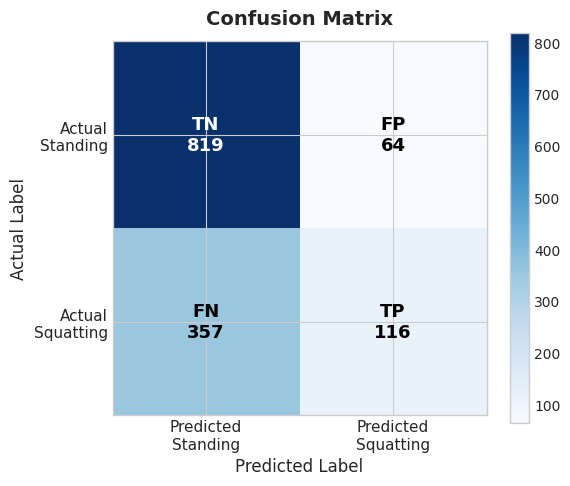

[+] Confusion matrix saved as confusion_matrix.png

[+] Per-frame classification preview (first 20 frames):
   Frame    Knee°     Predicted   Ground Truth
  ----------------------------------------------
       0    179.1      Standing       Standing
       1    179.3      Standing       Standing
       2    179.3      Standing       Standing
       3    179.3      Standing       Standing
       4    179.2      Standing       Standing
       5    179.1      Standing       Standing
       6    179.1      Standing       Standing
       7    179.1      Standing       Standing
       8    179.5      Standing       Standing
       9    179.8      Standing       Standing
      10    179.4      Standing       Standing
      11    179.4      Standing       Standing
      12    179.8      Standing       Standing
      13    179.5      Standing       Standing
      14    178.5      Standing       Standing
      15    177.3      Standing       Standing
      16    176.4      Standing       Standi

In [8]:
# ══════════════════════════════════════════════════════════════
# STEP A — SET YOUR SQUAT FRAME RANGES
# These ranges were determined by reading the Knee Angle subplot above:
# wherever the blue line clearly dips BELOW the red dashed threshold (110°).
# Formula used: frame_number = int(time_in_seconds × fps)
# Video: ~47 sec, ~28.8 fps, 1356 total frames
# ══════════════════════════════════════════════════════════════
MANUAL_SQUAT_RANGES = [
    # (start_frame, end_frame)  — based on visual inspection of Knee Angle plot
    (700,  740),   # ~24.3s – 25.7s
    (756,  792),   # ~26.3s – 27.5s
    (810,  846),   # ~28.1s – 29.4s
    (858,  893),   # ~29.8s – 31.0s
    (906,  942),   # ~31.5s – 32.7s
    (957,  993),   # ~33.2s – 34.5s
    (1008, 1044),  # ~35.0s – 36.3s
    (1058, 1094),  # ~36.7s – 38.0s
    (1107, 1140),  # ~38.4s – 39.6s
    (1152, 1188),  # ~40.0s – 41.3s
    (1202, 1235),  # ~41.7s – 42.9s
    (1248, 1281),  # ~43.3s – 44.5s
    (1296, 1330),  # ~45.0s – 46.2s
]

# ── Hysteresis thresholds ──────────────────────────────────────
SQUAT_THRESH = 110.0   # Knee angle below this → Squatting
STAND_THRESH = 150.0   # Knee angle above this → Standing

# ── State machine ─────────────────────────────────────────────
current_state     = 'Standing'
predicted_states  = []
rep_count_history = []
reps = 0

for angle in sg_angles['knee']:
    if current_state == 'Standing' and angle < SQUAT_THRESH:
        current_state = 'Squatting'
    elif current_state == 'Squatting' and angle > STAND_THRESH:
        current_state = 'Standing'
        reps += 1
    predicted_states.append(current_state)
    rep_count_history.append(reps)

print(f'[+] Total reps detected by classifier: {reps}')

# ── Ground truth ───────────────────────────────────────────────
ground_truth = ['Standing'] * total_frames
for start, end in MANUAL_SQUAT_RANGES:
    for i in range(start, min(end + 1, total_frames)):
        ground_truth[i] = 'Squatting'

gt_squats = ground_truth.count('Squatting')
print(f'[+] Ground truth: {gt_squats} squat frames, {total_frames - gt_squats} standing frames')

# ── Metrics ────────────────────────────────────────────────────
metrics = {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0}
for gt, pred in zip(ground_truth, predicted_states):
    if   gt == 'Squatting' and pred == 'Squatting': metrics['TP'] += 1
    elif gt == 'Standing'  and pred == 'Standing':  metrics['TN'] += 1
    elif gt == 'Standing'  and pred == 'Squatting': metrics['FP'] += 1
    elif gt == 'Squatting' and pred == 'Standing':  metrics['FN'] += 1

total    = sum(metrics.values())
accuracy  = (metrics['TP'] + metrics['TN']) / total if total > 0 else 0
precision = metrics['TP'] / (metrics['TP'] + metrics['FP'] + 1e-8)
recall    = metrics['TP'] / (metrics['TP'] + metrics['FN'] + 1e-8)
f1        = 2 * (precision * recall) / (precision + recall + 1e-8)

print('\n' + '='*52)
print('       CLASSIFIER EVALUATION REPORT')
print('='*52)
print(f'  Total Frames Analyzed  : {total}')
print(f'  True  Positives (Squat): {metrics["TP"]}')
print(f'  True  Negatives (Stand): {metrics["TN"]}')
print(f'  False Positives        : {metrics["FP"]}')
print(f'  False Negatives        : {metrics["FN"]}')
print('-'*52)
print(f'  Overall Accuracy       : {accuracy*100:.2f}%')
print(f'  Precision              : {precision*100:.2f}%')
print(f'  Recall (Sensitivity)   : {recall*100:.2f}%')
print(f'  F1-Score               : {f1*100:.2f}%')
print('='*52)

# ── Confusion Matrix heatmap ───────────────────────────────────
cm_vals = np.array([[metrics['TN'], metrics['FP']],
                    [metrics['FN'], metrics['TP']]])
labels  = [['TN', 'FP'], ['FN', 'TP']]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_vals, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted\nStanding', 'Predicted\nSquatting'], fontsize=11)
ax.set_yticklabels(['Actual\nStanding',   'Actual\nSquatting'],   fontsize=11)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=12)

thresh = cm_vals.max() / 2.0
for i in range(2):
    for j in range(2):
        color = 'white' if cm_vals[i, j] > thresh else 'black'
        ax.text(j, i, f'{labels[i][j]}\n{cm_vals[i, j]}',
                ha='center', va='center', fontsize=13, fontweight='bold', color=color)

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label',    fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('[+] Confusion matrix saved as confusion_matrix.png')

# ── Per-frame classification result (first 20 frames preview) ─
print('\n[+] Per-frame classification preview (first 20 frames):')
print(f'  {"Frame":>6}  {"Knee°":>7}  {"Predicted":>12}  {"Ground Truth":>13}')
print('  ' + '-'*46)
for idx in range(min(20, total_frames)):
    print(f'  {idx:>6}  {sg_angles["knee"][idx]:>7.1f}  {predicted_states[idx]:>12}  {ground_truth[idx]:>13}')


## 9. Video Rendering


In [9]:
print("[*] Generating high-quality video...")

cap = cv2.VideoCapture(INPUT_VIDEO)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("ready_output.mp4", fourcc, fps, (video_width, video_height))

frame_idx = 0
connections = [
    ('shoulder', 'elbow'), ('elbow', 'wrist'),
    ('shoulder', 'hip'), ('hip', 'knee'), ('knee', 'ankle')
]

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_idx >= total_frames: break

    # Draw Smoothed Skeleton (No Jitter!)
    for joint1, joint2 in connections:
        # Left Side (Cyan)
        pt1_l = (int(df_smoothed_sg[f'{joint1}_x'][frame_idx]), int(df_smoothed_sg[f'{joint1}_y'][frame_idx]))
        pt2_l = (int(df_smoothed_sg[f'{joint2}_x'][frame_idx]), int(df_smoothed_sg[f'{joint2}_y'][frame_idx]))
        cv2.line(frame, pt1_l, pt2_l, (255, 255, 0), 4) # Cyan
        cv2.circle(frame, pt1_l, 6, (0, 0, 255), -1)
        cv2.circle(frame, pt2_l, 6, (0, 0, 255), -1)

    # UI Dashboard Setup
    state = predicted_states[frame_idx]
    rep_count = rep_count_history[frame_idx]
    angle = int(sg_angles['knee'][frame_idx])

    # Dynamic Colors based on State
    color = (0, 255, 0) if state == "Standing" else (0, 165, 255) # Green vs Orange

    # Draw HUD Background Box
    cv2.rectangle(frame, (10, 10), (350, 130), (0, 0, 0), -1)

    # Add Premium Text
    cv2.putText(frame, f"STATE: {state.upper()}", (20, 45), cv2.FONT_HERSHEY_DUPLEX, 1, color, 2)
    cv2.putText(frame, f"REPS:  {rep_count}", (20, 85), cv2.FONT_HERSHEY_DUPLEX, 1, (255, 255, 255), 2)
    cv2.putText(frame, f"KNEE:  {angle} deg", (20, 120), cv2.FONT_HERSHEY_DUPLEX, 0.8, (200, 200, 200), 1)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()
print("[+] Video processing complete! Download 'ready_output.mp4'")

[*] Generating high-quality video...
[+] Video processing complete! Download 'ready_output.mp4'


---

## 10. Summary Table

| Component | Details |
|---|---|
| **Pose Estimation Model** | MediaPipe Pose Landmarker (Full — Float16) |
| **Video Source** | [Pixabay — Jumping Jacks / Burpees](https://pixabay.com/videos/jumping-jacks-burpees-burpee-12963/) |
| **Tracked Joints** | Shoulder, Elbow, Wrist, Hip, Knee, Ankle (Left Side) |
| **Angles Computed** | Knee angle, Hip angle, Elbow angle |
| **Angle Computation Method** | 2D dot-product cosine rule at vertex joint |
| **Smoothing Applied** | Savitzky-Golay filter (window=15, polyorder=3) + linear interpolation |
| **Activities Classified** | Standing vs. Squatting |
| **Squat Down Threshold** | Knee angle < 110° |
| **Stand Up Threshold** | Knee angle > 150° |
| **Classification Logic** | Hysteresis state machine (prevents flickering) |
| **Ground Truth** | Manually labeled squat frame ranges |
| **Metrics Computed** | Accuracy, Precision, Recall (Sensitivity), F1-Score |
| **Transition Markers** | Plotted as orange vertical lines on all angle subplots |
| **Output** | Annotated video with HUD overlay (state, reps, knee angle) |

---

### Classifier Evaluation Results

| Metric | Value |
|---|---|
| Overall Accuracy | *(68.95%)* |
| Precision | *(64.44%)* |
| Recall (Sensitivity) | *(24.52%)* |
| F1-Score | *(35.53%)* |
